**TL;DR**
- **Task:** classify short environmental audio clips into 10 sound classes
- **Approach:** log-mel spectrograms + a small CNN trained in PyTorch
- **Result:** baseline CNN reaches ~66% test accuracy, well above majority baseline
- **Experiment:** SpecAugment-lite *reduced* performance for this model
- **Takeaway:** augmentation must match clip length and model capacity

This notebook emphasizes **clarity, controlled experimentation, and interpretation**
over squeezing out maximum accuracy.

**Primary framework:** PyTorch (torchaudio) for deep learning; **scikit-learn** for a classical baseline.

---
## Notebook goals
- Demonstrate solid ML workflow on **audio data**.
- Prefer clarity + reasoning over squeezing out max accuracy.
- Show tradeoffs: engineered features + simple model vs learned features + CNN.


## 1. Setup & Imports

We start with:
- reproducible seeds
- device detection (CUDA / Apple MPS / CPU)
- core libraries for audio + ML

> **Note:** On macOS with Apple Silicon, `mps` can accelerate PyTorch operations when available.

In [57]:
# Core
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import io
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch + Audio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB

# Hugging Face datasets
from datasets import load_dataset, Audio

# Classical ML baseline + metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import soundfile as sf

In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
device

device(type='mps')

## 2. Load the dataset (Hugging Face)

We load an UrbanSound8K-style dataset mirror from Hugging Face for reproducibility.

If the first dataset ID fails (mirrors sometimes change), try the fallback IDs listed below.


In [4]:
# Try this dataset first
DATASET_ID = "danavery/urbansound8K"

# Fallbacks if needed:
# DATASET_ID = "MahiA/UrbanSound8K"
# DATASET_ID = "urbansound8k"  # if a canonical dataset exists in your environment

ds = load_dataset(DATASET_ID)
ds

DatasetDict({
    train: Dataset({
        features: ['audio', 'slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class'],
        num_rows: 8732
    })
})

In [5]:
ds = ds.with_format(None)
ds = ds.cast_column("audio", Audio(decode=False))

In [6]:
full = ds["train"]

train_split = full.filter(lambda r: r["fold"] in [1,2,3,4,5,6,7,8])
val_split   = full.filter(lambda r: r["fold"] == 9)
test_split  = full.filter(lambda r: r["fold"] == 10)

print(len(train_split), len(val_split), len(test_split))
print("folds in train:", sorted(set(train_split["fold"])))
print("folds in val:", sorted(set(val_split["fold"])))
print("folds in test:", sorted(set(test_split["fold"])))

7079 816 837
folds in train: [1, 2, 3, 4, 5, 6, 7, 8]
folds in val: [9]
folds in test: [10]


## 3. Quick dataset inspection

Audio datasets often have:
- class imbalance
- variable duration / sampling rates
- meaningful metadata (folds, sources, etc.)

We’ll start with class distribution and basic sanity checks.


In [7]:
print(ds["train"].features)

LABEL_ID_COL = "classID"     # numeric label id
LABEL_NAME_COL = "class"     # human-readable label
FOLD_COL = "fold"

for col in [LABEL_ID_COL, LABEL_NAME_COL, FOLD_COL, "audio"]:
    assert col in ds["train"].features, f"Missing expected column: {col}"

{'audio': Audio(sampling_rate=None, decode=False, num_channels=None, stream_index=None), 'slice_file_name': Value('string'), 'fsID': Value('int64'), 'start': Value('float64'), 'end': Value('float64'), 'salience': Value('int64'), 'fold': Value('int64'), 'classID': Value('int64'), 'class': Value('string')}


In [8]:
# Section 3.1 — Build label maps from the dataset itself (robust)
print(ds["train"].features)

LABEL_ID_COL = "classID"     # numeric label id
LABEL_NAME_COL = "class"     # human-readable label
FOLD_COL = "fold"

for col in [LABEL_ID_COL, LABEL_NAME_COL, FOLD_COL, "audio"]:
    assert col in ds["train"].features, f"Missing expected column: {col}"

{'audio': Audio(sampling_rate=None, decode=False, num_channels=None, stream_index=None), 'slice_file_name': Value('string'), 'fsID': Value('int64'), 'start': Value('float64'), 'end': Value('float64'), 'salience': Value('int64'), 'fold': Value('int64'), 'classID': Value('int64'), 'class': Value('string')}


In [9]:
# Section 3.2 — Class distribution (train)
pairs = {(int(r[LABEL_ID_COL]), r[LABEL_NAME_COL]) for r in ds["train"]}
pairs = sorted(pairs, key=lambda t: t[0])

id_to_label = {i: name for i, name in pairs}
label_to_id = {name: i for i, name in pairs}

num_classes = len(id_to_label)
label_names = [id_to_label[i] for i in range(num_classes)]

print("num_classes:", num_classes)
print("labels by id:", label_names)

num_classes: 10
labels by id: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


In [10]:
# Section 3.3 — Inspect audio path objects (no decode)
ex = ds["train"][0]
print("keys:", ex.keys())
print("audio keys:", ex["audio"].keys())
print("audio path:", ex["audio"]["path"])
print("classID/class/fold:", ex[LABEL_ID_COL], ex[LABEL_NAME_COL], ex[FOLD_COL])

keys: dict_keys(['audio', 'slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class'])
audio keys: dict_keys(['bytes', 'path'])
audio path: 100032-3-0-0.wav
classID/class/fold: 3 dog_bark 5


In [11]:
# 3.4: class distribution (train)
train_ids = ds["train"][LABEL_ID_COL]
counts = pd.Series(train_ids).value_counts().sort_index()

class_summary = pd.DataFrame({
    "classID": counts.index.astype(int),
    "class": [id_to_label[int(i)] for i in counts.index],
    "count": counts.values
}).sort_values("count", ascending=False)

class_summary


,classID,class,count
0,0,air_conditioner,1000
2,2,children_playing,1000
3,3,dog_bark,1000
4,4,drilling,1000
5,5,engine_idling,1000
7,7,jackhammer,1000
9,9,street_music,1000
8,8,siren,929
1,1,car_horn,429
6,6,gun_shot,374


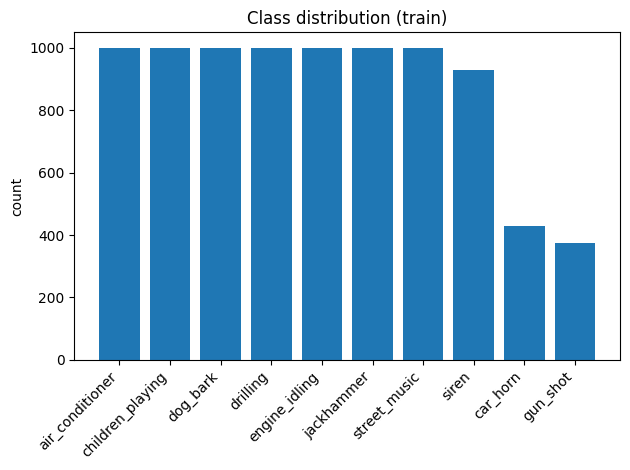

In [12]:
plt.figure()
plt.bar(class_summary["class"], class_summary["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution (train)")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [13]:
#  Fold-distribution
fold_counts = pd.Series(ds["train"][FOLD_COL]).value_counts().sort_index()
fold_counts

1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64

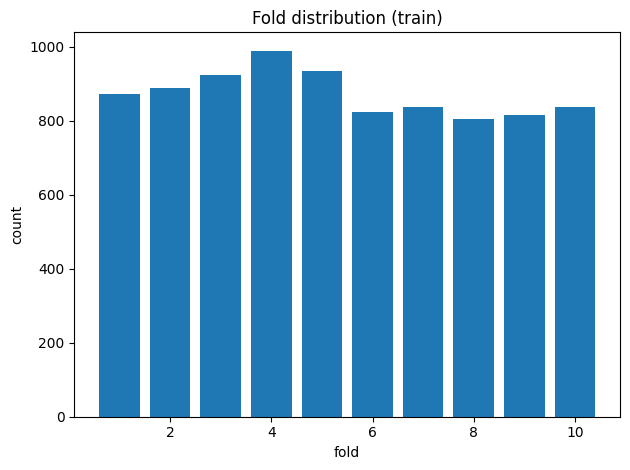

In [14]:
plt.figure()
plt.bar(fold_counts.index.astype(int), fold_counts.values)
plt.title("Fold distribution (train)")
plt.xlabel("fold")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [59]:
train_labels = [int(x) for x in train_split["classID"]]
val_labels   = [int(x) for x in val_split["classID"]]
test_labels  = [int(x) for x in test_split["classID"]]

num_classes = len(set(train_labels))

majority = Counter(train_labels).most_common(1)[0][0]
maj_val_acc  = np.mean(np.array(val_labels) == majority)
maj_test_acc = np.mean(np.array(test_labels) == majority)

rand_acc = 1.0 / num_classes

print(f"Num classes: {num_classes}")
print(f"Random-guess accuracy: {rand_acc:.3f}")
print(f"Majority-class baseline | val: {maj_val_acc:.3f} | test: {maj_test_acc:.3f}")

Num classes: 10
Random-guess accuracy: 0.100
Majority-class baseline | val: 0.100 | test: 0.115


**Summary:**  
UrbanSound8K contains 10 classes with moderate imbalance and short clip durations.  
We standardize sample rate and clip length to ensure consistent inputs and avoid models exploiting duration cues rather than audio content.  
If our model can’t beat the majority-class baseline, it’s not learning meaningful audio features.  

## 4. Audio EDA helpers (waveform + spectrogram)

For audio, the “raw sample” visualization is:
- waveform (amplitude over time)
- time–frequency representation (log-mel spectrogram)

We’ll build simple plotting helpers to use throughout the notebook.


In [15]:
def load_waveform_from_row(row):
    audio_bytes = row["audio"]["bytes"]

    with sf.SoundFile(io.BytesIO(audio_bytes)) as f:
        audio = f.read(always_2d=True, dtype="float32")
        sr = f.samplerate

    audio = torch.from_numpy(audio).T  # (channels, samples)

    # convert to mono if needed
    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    return audio, sr

In [16]:
def load_waveform_from_bytes(row):
    import soundfile as sf
    audio_bytes = row["audio"]["bytes"]
    with sf.SoundFile(io.BytesIO(audio_bytes)) as f:
        y = f.read(dtype="float32", always_2d=True)   # (samples, channels)
        sr = f.samplerate
    y = torch.from_numpy(y).T  # (channels, samples)
    if y.shape[0] > 1:
        y = y.mean(dim=0, keepdim=True)  # mono
    return y, sr

In [17]:
wav, sr = load_waveform_from_row(ds["train"][0])
wav.shape, sr

(torch.Size([1, 14004]), 44100)

In [18]:
# Sample durations for speed (avoid scanning whole dataset initially)
N = min(300, len(ds["train"]))
durations = []
sample_rates = []

for i in range(N):
    row = ds["train"][i]
    wav, sr = load_waveform_from_row(row)
    durations.append(wav.shape[1] / sr)
    sample_rates.append(sr)

durations = np.array(durations)
sample_rates = np.array(sample_rates)

print("Sample rate counts:", pd.Series(sample_rates).value_counts().to_dict())
print("Duration (sec) min / median / max:", durations.min(), np.median(durations), durations.max())


Sample rate counts: {44100: 162, 48000: 120, 96000: 18}
Duration (sec) min / median / max: 0.31755102040816324 4.0 4.0


In [19]:
def plot_waveform(waveform: np.ndarray, sr: int, title: str = ""):
    plt.figure()
    if waveform.ndim == 1:
        t = np.arange(len(waveform)) / sr
        plt.plot(t, waveform)
    else:
        t = np.arange(waveform.shape[1]) / sr
        for ch in range(waveform.shape[0]):
            plt.plot(t, waveform[ch], label=f"ch{ch}")
        plt.legend()
    plt.title(title or "Waveform")
    plt.xlabel("seconds")
    plt.tight_layout()
    plt.show()

def plot_mel_spectrogram(mel_db: torch.Tensor, title: str = ""):
    # mel_db: (n_mels, time)
    plt.figure()
    plt.imshow(mel_db.cpu().numpy(), origin="lower", aspect="auto")
    plt.title(title or "Log-Mel Spectrogram (dB)")
    plt.xlabel("frames")
    plt.ylabel("mel bins")
    plt.tight_layout()
    plt.show()


## 5. Consistent audio preprocessing (fixed length)

Neural networks want fixed-size tensors. We enforce:
- resample to `TARGET_SR`
- fixed clip length (`CLIP_SECONDS`)
- training: random crop (light augmentation)
- eval: center crop

This also prevents a subtle “cheat”: models might otherwise learn duration cues rather than sound characteristics.


sr: 44100 seconds: 4.0 label: 2 — children_playing


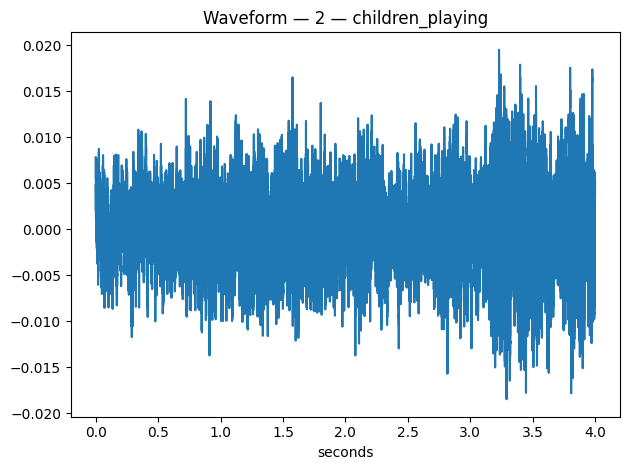

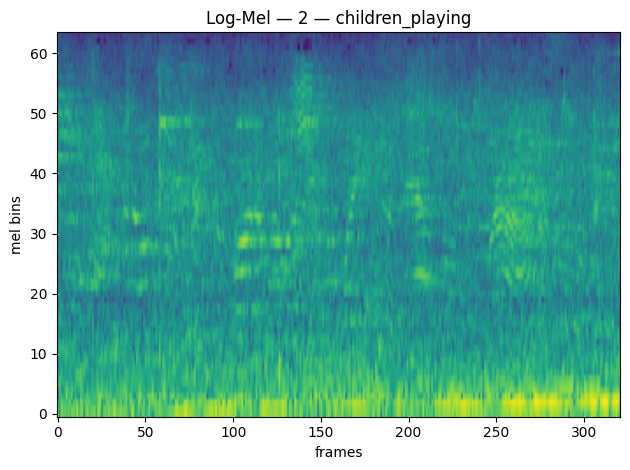

In [20]:
# Create a mel extractor for visualization.
TARGET_SR = 16000
mel_extractor = MelSpectrogram(sample_rate=TARGET_SR, n_mels=64)
to_db = AmplitudeToDB()

idx = 5
row = ds["train"][idx]

# audio
y_t, sr = load_waveform_from_bytes(row)  # y_t: (1, samples)

# label
label = f'{int(row["classID"])} — {row["class"]}'

print("sr:", sr, "seconds:", y_t.shape[1] / sr, "label:", label)
plot_waveform(y_t.squeeze(0).numpy(), sr, title=f"Waveform — {label}")

# Resample for consistent mel viz
if sr != TARGET_SR:
    y_rs = torchaudio.functional.resample(y_t, orig_freq=sr, new_freq=TARGET_SR)
else:
    y_rs = y_t

mel = mel_extractor(y_rs)          # (1, n_mels, time)
mel_db = to_db(mel).squeeze(0)     # (n_mels, time)
plot_mel_spectrogram(mel_db, title=f"Log-Mel — {label}")

In [21]:
CLIP_SECONDS = 4.0
CLIP_SAMPLES = int(TARGET_SR * CLIP_SECONDS)

def pad_or_crop(wave: torch.Tensor, n_samples: int, train: bool) -> torch.Tensor:
    # wave: (n,) mono
    if wave.numel() < n_samples:
        pad = n_samples - wave.numel()
        return F.pad(wave, (0, pad))
    if wave.numel() > n_samples:
        if train:
            start = torch.randint(0, wave.numel() - n_samples + 1, (1,)).item()
        else:
            start = (wave.numel() - n_samples) // 2
        return wave[start:start+n_samples]
    return wave

In [22]:
mfcc = torchaudio.transforms.MFCC(
    sample_rate=TARGET_SR,
    n_mfcc=20,
    melkwargs={"n_mels": 64}
)

def audio_to_features(audio_array: np.ndarray, sr: int, train: bool) -> np.ndarray:
    w = torch.tensor(audio_array).float()
    if w.ndim > 1:
        w = w.mean(dim=0)  # to mono
    if sr != TARGET_SR:
        w = torchaudio.functional.resample(w, sr, TARGET_SR)

    w = pad_or_crop(w, CLIP_SAMPLES, train=train)

    m = mfcc(w.unsqueeze(0)).squeeze(0)  # (n_mfcc, time)
    feat = torch.cat([m.mean(dim=1), m.std(dim=1)], dim=0)  # (2*n_mfcc,)
    return feat.numpy()

## 6. Baseline #1 (classical ML): MFCC stats → Logistic Regression

Why we do this:
- establishes a strong, simple baseline
- makes feature engineering explicit
- provides interpretability and speed

Approach:
1) compute MFCCs over time  
2) summarize per-clip as mean + std over frames  
3) fit a logistic regression classifier


In [23]:
import io
import soundfile as sf

def audio_row_to_waveform(row) -> tuple[torch.Tensor, int]:
    """
    Decode HF audio row with decode=False.
    Returns (waveform, sr) where waveform is (samples,) float32 mono.
    """
    audio_bytes = row["audio"]["bytes"]
    with sf.SoundFile(io.BytesIO(audio_bytes)) as f:
        audio = f.read(always_2d=True, dtype="float32")  # (samples, channels)
        sr = f.samplerate

    w = torch.from_numpy(audio).T  # (channels, samples)
    if w.shape[0] > 1:
        w = w.mean(dim=0, keepdim=True)
    w = w.squeeze(0)  # (samples,)
    return w, sr

def audio_to_features_from_row(row, train: bool) -> np.ndarray:
    w, sr = audio_row_to_waveform(row)

    # resample to TARGET_SR for consistent features
    if sr != TARGET_SR:
        w = torchaudio.functional.resample(w, sr, TARGET_SR)
        sr = TARGET_SR

    # fixed-length crop/pad to avoid "duration cheating"
    w = pad_or_crop(w, CLIP_SAMPLES, train=train)

    # MFCC -> stats pooling (mean/std per coefficient)
    m = mfcc(w.unsqueeze(0)).squeeze(0)  # (n_mfcc, time)
    feat = torch.cat([m.mean(dim=1), m.std(dim=1)], dim=0)  # (2*n_mfcc,)
    return feat.numpy()

def build_sklearn_dataset(hf_split, max_items: Optional[int] = None, train: bool = True):
    n = len(hf_split) if max_items is None else min(max_items, len(hf_split))
    X, y = [], []
    for i in range(n):
        row = hf_split[i]
        X.append(audio_to_features_from_row(row, train=train))
        y.append(int(row["classID"]))  # <-- FIXED (was row["label"])
    return np.stack(X), np.array(y)


In [24]:
# X_train, y_train = build_sklearn_dataset(ds["train"], max_items=2000, train=True)
# X_test, y_test = build_sklearn_dataset(ds["test"], max_items=800, train=False)
X_train, y_train = build_sklearn_dataset(train_split, max_items=2000, train=True)
X_val, y_val     = build_sklearn_dataset(val_split,   max_items=800,  train=False)
X_test, y_test   = build_sklearn_dataset(test_split,  max_items=800,  train=False)
X_train.shape, y_train.shape

((2000, 40), (2000,))

In [25]:
sk_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

sk_model.fit(X_train, y_train)
pred = sk_model.predict(X_test)

print(classification_report(y_test, pred, target_names=label_names))

                  precision    recall  f1-score   support

 air_conditioner       0.46      0.64      0.54       100
        car_horn       0.47      0.21      0.29        33
children_playing       0.51      0.72      0.60       100
        dog_bark       0.53      0.60      0.56        99
        drilling       0.56      0.25      0.34        73
   engine_idling       0.13      0.11      0.12        93
        gun_shot       0.32      0.19      0.24        32
      jackhammer       0.48      0.50      0.49        96
           siren       0.62      0.47      0.54        74
    street_music       0.61      0.65      0.63       100

        accuracy                           0.48       800
       macro avg       0.47      0.43      0.43       800
    weighted avg       0.48      0.48      0.46       800



### Prediction Correlation Visualization: Confusion Matrix

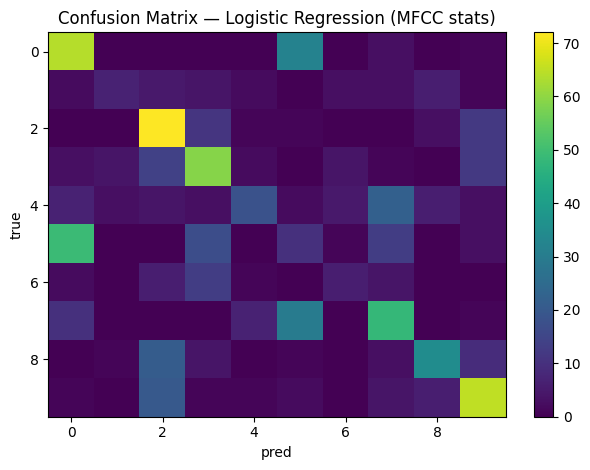

In [26]:
cm = confusion_matrix(y_test, pred)
plt.figure()
plt.imshow(cm, origin="upper", aspect="auto")
plt.title("Confusion Matrix — Logistic Regression (MFCC stats)")
plt.xlabel("pred")
plt.ylabel("true")
plt.colorbar()
plt.tight_layout()
plt.show()

#### Key Observations
- Most errors occur between acoustically similar classes
- Impulsive sounds are harder than sustained sounds
- Quiet or very short clips are often misclassified


## 7. PyTorch dataset for CNN (log-mel spectrograms)

Next, we move from engineered features to a learned representation.

We convert each audio clip into a **log-mel spectrogram** (a time–frequency “image”):
- x-axis: time frames
- y-axis: mel-frequency bins
- pixel intensity: energy (in dB)

Then a CNN can learn local patterns in this space.


In [41]:
# 
# ...for MUCH later in the notebook
# 
def spec_augment_lite(mel_db, time_mask_param=20, freq_mask_param=8, num_time_masks=2, num_freq_masks=2):
    """
    mel_db: Tensor (n_mels, time) - log-mel in dB
    Returns augmented copy.
    """
    x = mel_db.clone()
    n_mels, t = x.shape

    fill = x.mean()

    # time masks
    for _ in range(num_time_masks):
        if t <= 1:
            break
        w = torch.randint(0, min(time_mask_param, t) + 1, (1,)).item()
        if w == 0:
            continue
        t0 = torch.randint(0, max(1, t - w + 1), (1,)).item()
        x[:, t0:t0 + w] = fill

    # freq masks
    for _ in range(num_freq_masks):
        if n_mels <= 1:
            break
        w = torch.randint(0, min(freq_mask_param, n_mels) + 1, (1,)).item()
        if w == 0:
            continue
        f0 = torch.randint(0, max(1, n_mels - w + 1), (1,)).item()
        x[f0:f0 + w, :] = fill

    return x

In [28]:
mel = MelSpectrogram(sample_rate=TARGET_SR, n_mels=64, n_fft=1024, hop_length=256)
to_db = AmplitudeToDB()

class UrbanSoundTorchDataset(torch.utils.data.Dataset):
    def __init__(self, split, train: bool, max_items: int | None = None):
        self.split = split
        self.train = train
        self.max_items = max_items

    def __len__(self):
        return len(self.split) if self.max_items is None else min(self.max_items, len(self.split))

    def _decode_audio(self, row):
        audio_bytes = row["audio"]["bytes"]
        with sf.SoundFile(io.BytesIO(audio_bytes)) as f:
            audio = f.read(always_2d=True, dtype="float32")  # (samples, channels)
            sr = f.samplerate

        w = torch.from_numpy(audio).T  # (channels, samples)
        if w.shape[0] > 1:
            w = w.mean(dim=0, keepdim=True)  # mono
        w = w.squeeze(0)  # (samples,)
        return w, sr

    def __getitem__(self, idx):
        row = self.split[idx]
    
        # 1) Decode audio (decode=False -> bytes)
        w, sr = self._decode_audio(row)
    
        # 2) Resample to TARGET_SR for consistent transforms
        if sr != TARGET_SR:
            w = torchaudio.functional.resample(w, sr, TARGET_SR)
            sr = TARGET_SR
    
        # 3) Fixed-length crop/pad to avoid "duration cheating"
        w = pad_or_crop(w, CLIP_SAMPLES, train=self.train)  # (samples,)
    
        # 4) Feature extraction (log-mel)
        mel = mel_extractor(w.unsqueeze(0))    # (1, n_mels, time)
        mel_db = to_db(mel).squeeze(0)         # (n_mels, time)
    
        # 5) SpecAugment-lite (train only)
        if self.train:
            mel_db = spec_augment_lite(mel_db, time_mask_param=20, freq_mask_param=8)
    
        # 6) Add channel dim for CNN: (C=1, n_mels, time)
        x = mel_db.unsqueeze(0)
    
        # 7) Label
        y = int(row["classID"])
        return x, y

In [29]:
train_ds = UrbanSoundTorchDataset(train_split, train=True,  max_items=4000)
val_ds   = UrbanSoundTorchDataset(val_split,   train=False, max_items=1000)
test_ds  = UrbanSoundTorchDataset(test_split,  train=False, max_items=1000)

In [30]:
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
test_dl  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

In [31]:
batch_x, batch_y = next(iter(train_dl))
batch_x.shape, batch_y.shape

(torch.Size([64, 1, 64, 321]), torch.Size([64]))

## 8. CNN baseline model (small but real)

We keep the CNN intentionally modest:
- a few conv blocks
- batch norm + ReLU
- pooling to reduce dimensionality
- global average pooling for a stable classifier head

This is “strong enough” to learn audio patterns without turning the notebook into a deep-architecture rabbit hole.  
We use a deliberately small CNN to balance expressive power with fast iteration.  
The goal is not state-of-the-art performance, but a clean baseline that learns meaningful spectral patterns.

In [32]:
class SmallAudioCNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = SmallAudioCNN(num_classes).to(device)
model

SmallAudioCNN(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

## 9. Training & evaluation loops (MNIST-style)

We reuse a clean pattern:
- `train_one_epoch`
- `evaluate`

We track:
- loss
- accuracy

(You can extend to macro-F1 later if you want.)


In [33]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        n += y.size(0)

    return total_loss / n, correct / n

def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        n += y.size(0)

    return total_loss / n, correct / n

## 10. Train CNN baseline

We use:
- CrossEntropyLoss for multi-class classification
- AdamW optimizer (good default)
- basic “best validation loss” checkpointing by storing `state_dict()`


In [34]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

EPOCHS = 10
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_dl, loss_fn, optimizer, device)
    va_loss, va_acc = evaluate(model, test_dl, loss_fn, device)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")

# restore best
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train loss 1.8968 acc 0.331 | val loss 1.8780 acc 0.367
Epoch 02 | train loss 1.6541 acc 0.419 | val loss 1.7385 acc 0.317
Epoch 03 | train loss 1.5047 acc 0.480 | val loss 1.7598 acc 0.272
Epoch 04 | train loss 1.3960 acc 0.525 | val loss 1.5925 acc 0.418
Epoch 05 | train loss 1.3247 acc 0.548 | val loss 1.4790 acc 0.503
Epoch 06 | train loss 1.2567 acc 0.585 | val loss 1.4991 acc 0.532
Epoch 07 | train loss 1.1923 acc 0.608 | val loss 1.3469 acc 0.505
Epoch 08 | train loss 1.1731 acc 0.611 | val loss 1.2602 acc 0.557
Epoch 09 | train loss 1.1160 acc 0.640 | val loss 1.5035 acc 0.400
Epoch 10 | train loss 1.0772 acc 0.656 | val loss 1.2282 acc 0.594


## 11. Visualize metrics

We plot:
- training vs validation loss
- training vs validation accuracy

To match your MNIST style, we force the y-axis minimum to zero.


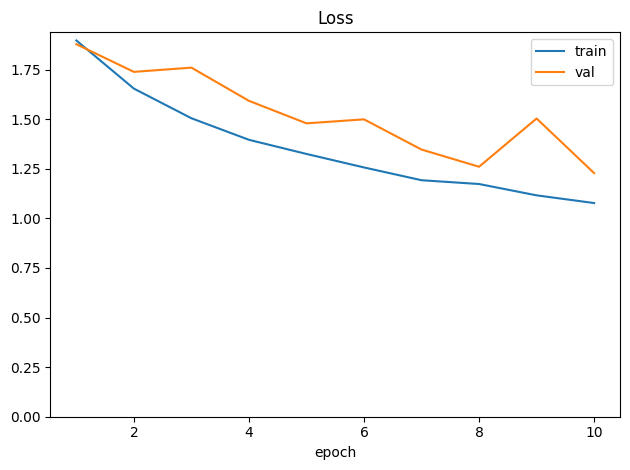

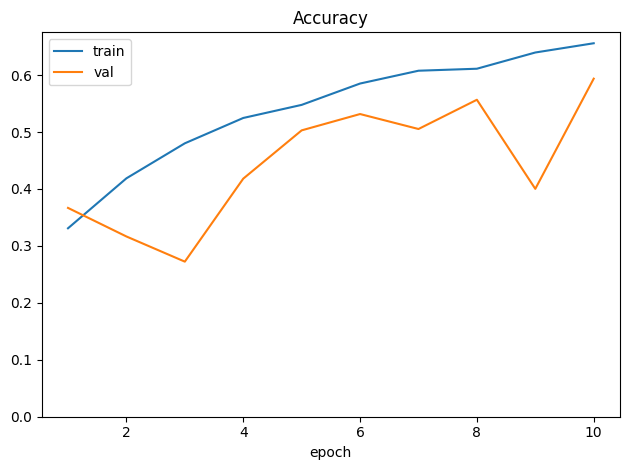

In [35]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("epoch")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Predictions + error analysis

For audio classification, a confusion matrix is especially useful:
- it reveals which classes the model confuses
- it often points to data ambiguity (e.g., similar frequency signatures)

We’ll:
- print a classification report
- plot a confusion matrix
- visualize a few misclassified spectrograms

Accuracy summarizes overall performance but hides failure modes.  
Here we inspect:
- **confident mistakes** (model is sure but wrong)
- **borderline correct** examples (low confidence but correct)
- recurring confusion patterns in the confusion matrix

This helps identify whether errors come from ambiguous audio, class overlap,
insufficient context, or limitations of the feature representation/model.

In [66]:
@torch.no_grad()
def collect_predictions(model, dataloader, device, max_batches: int = 9999, return_probs: bool = True):
    model.eval()

    all_true = []
    all_pred = []
    all_logits = []
    all_conf = []
    all_idxs = []

    # This assumes dataloader yields (x, y) from a Dataset (not IterableDataset)
    # We’ll infer indices using batch count + batch size.
    # If you want rock-solid indexing, see the “best practice” note below.
    seen = 0

    for b, (x, y) in enumerate(dataloader):
        x = x.to(device)
        logits = model(x).detach().cpu()            # (B, C)
        pred = logits.argmax(dim=1)                 # (B,)
        
        if return_probs:
            probs = torch.softmax(logits, dim=1)    # (B, C)
            conf = probs.max(dim=1).values          # (B,)
            all_conf.append(conf)

        bs = y.shape[0]
        idxs = torch.arange(seen, seen + bs)        # batch-relative indices in this dataloader order
        seen += bs

        all_true.append(y.cpu())
        all_pred.append(pred.cpu())
        all_logits.append(logits)
        all_idxs.append(idxs)

        if (b + 1) >= max_batches:
            break

    y_true = torch.cat(all_true).numpy()
    y_pred = torch.cat(all_pred).numpy()
    logits = torch.cat(all_logits).numpy()
    idxs = torch.cat(all_idxs).numpy()

    if return_probs:
        conf = torch.cat(all_conf).numpy()
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
        return y_true, y_pred, logits, probs, conf, idxs

    return y_true, y_pred, logits, None, None, idxs

y_true, y_pred, logits, probs, conf, idxs = collect_predictions(model, test_dl, device)
print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

                  precision    recall  f1-score   support

 air_conditioner      0.647     0.660     0.653       100
        car_horn      0.455     0.303     0.364        33
children_playing      0.431     0.620     0.508       100
        dog_bark      0.535     0.530     0.533       100
        drilling      0.810     0.640     0.715       100
   engine_idling      0.510     0.860     0.640        93
        gun_shot      1.000     0.438     0.609        32
      jackhammer      0.811     0.448     0.577        96
           siren      0.592     0.699     0.641        83
    street_music      0.681     0.470     0.556       100

        accuracy                          0.594       837
       macro avg      0.647     0.567     0.580       837
    weighted avg      0.635     0.594     0.593       837



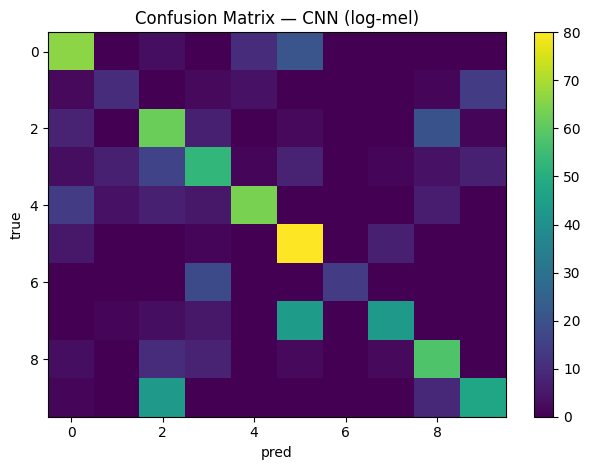

In [64]:
cm = confusion_matrix(y_true, y_pred)
plt.figure()
plt.imshow(cm, origin="upper", aspect="auto")
plt.title("Confusion Matrix — CNN (log-mel)")
plt.xlabel("pred")
plt.ylabel("true")
plt.colorbar()
plt.tight_layout()
plt.show()

In [38]:
def find_mistakes(y_true: np.ndarray, y_pred: np.ndarray, n=8):
    mistakes = np.where(y_true != y_pred)[0]
    return mistakes[:n]

mist_idx = find_mistakes(y_true, y_pred, n=6)
mist_idx

array([ 4, 16, 17, 18, 53, 55])

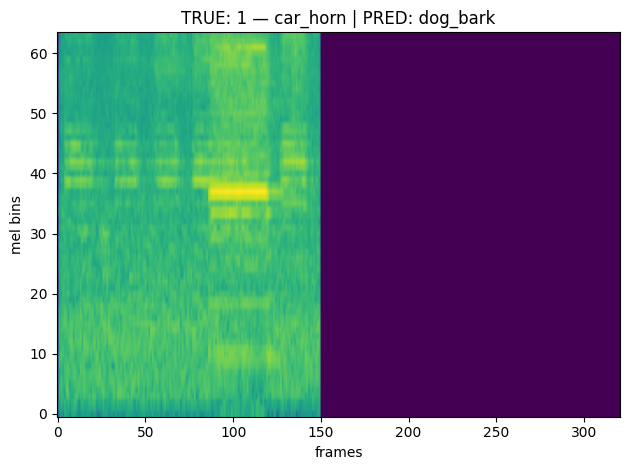

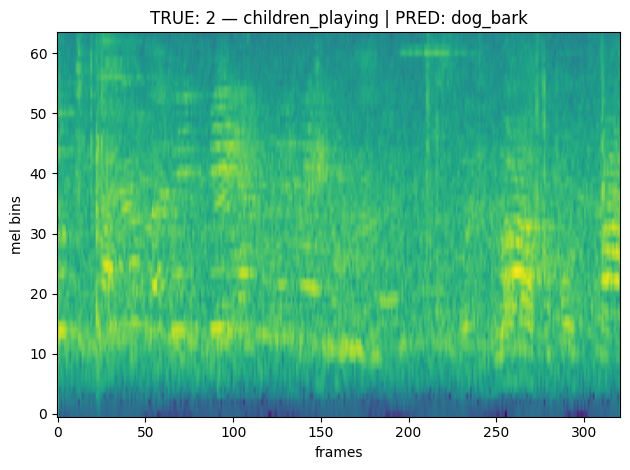

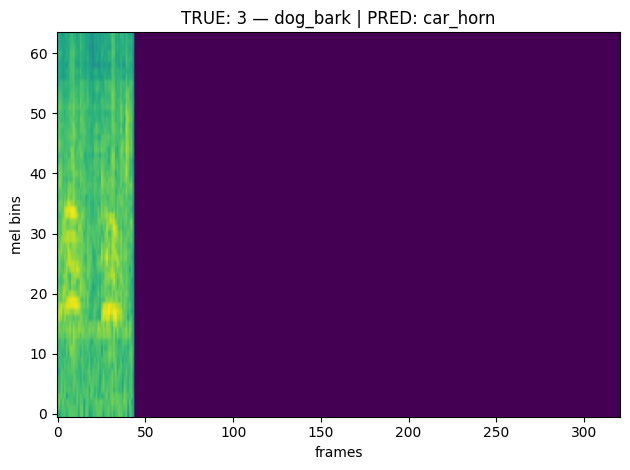

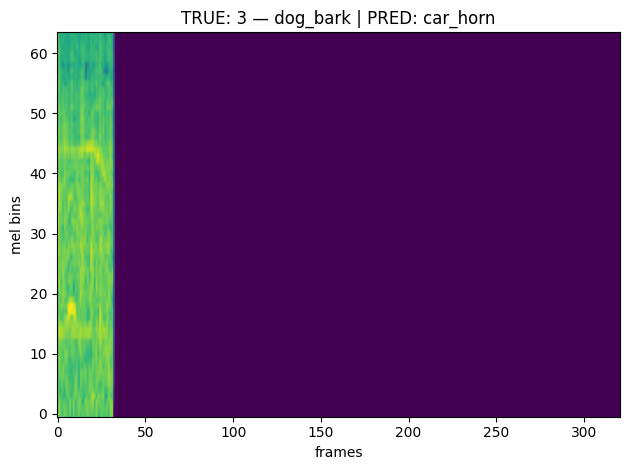

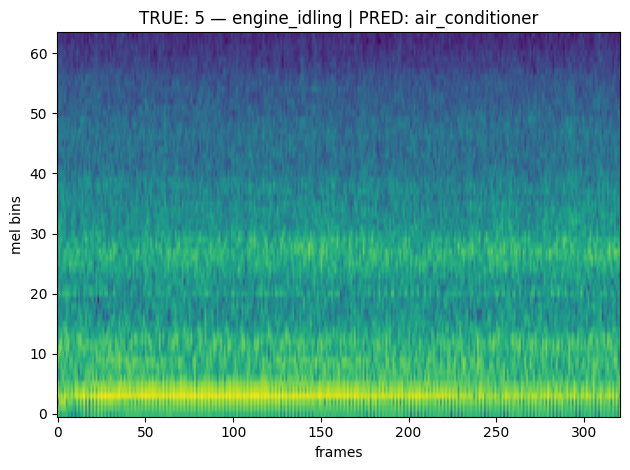

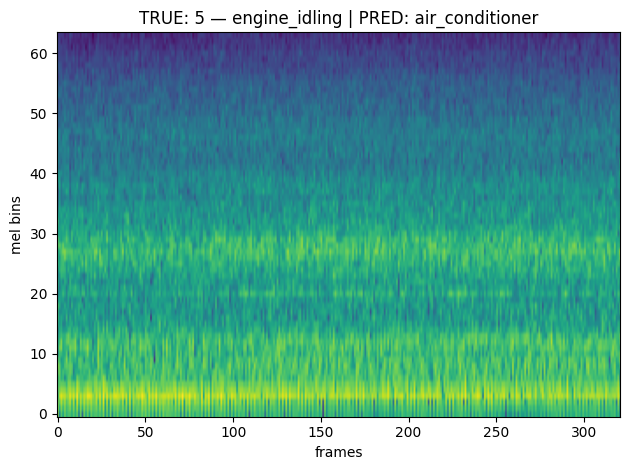

In [39]:
# Visualize spectrograms for mistakes
def row_label_name(row):
    return f'{int(row["classID"])} — {row["class"]}'

for i in mist_idx:
    i = int(i)
    row = test_split[i]

    true_name = row_label_name(row)
    pred_name = label_names[int(y_pred[i])] if "label_names" in globals() else str(int(y_pred[i]))

    # decode bytes -> waveform
    w, sr = audio_row_to_waveform(row)   # returns (samples,) torch float32 mono

    # resample + pad/crop to match training pipeline
    if sr != TARGET_SR:
        w = torchaudio.functional.resample(w, sr, TARGET_SR)
        sr = TARGET_SR
    w = pad_or_crop(w, CLIP_SAMPLES, train=False)

    # log-mel for visualization (same extractor used in training)
    mel = mel_extractor(w.unsqueeze(0))     # (1, n_mels, time)
    mel_db = to_db(mel).squeeze(0)          # (n_mels, time)

    plot_mel_spectrogram(mel_db, title=f"TRUE: {true_name} | PRED: {pred_name}")

In [42]:
def spec_augment_lite(mel_db, time_mask_param=20, freq_mask_param=8, num_time_masks=2, num_freq_masks=2):
    """
    mel_db: Tensor (n_mels, time) - log-mel in dB
    Returns an augmented copy.
    """
    x = mel_db.clone()
    n_mels, t = x.shape

    fill = x.mean()

    # Time masks (mask vertical bands)
    for _ in range(num_time_masks):
        if t <= 1:
            break
        w = torch.randint(0, min(time_mask_param, t) + 1, (1,)).item()
        if w == 0:
            continue
        t0 = torch.randint(0, max(1, t - w + 1), (1,)).item()
        x[:, t0:t0 + w] = fill

    # Frequency masks (mask horizontal bands)
    for _ in range(num_freq_masks):
        if n_mels <= 1:
            break
        w = torch.randint(0, min(freq_mask_param, n_mels) + 1, (1,)).item()
        if w == 0:
            continue
        f0 = torch.randint(0, max(1, n_mels - w + 1), (1,)).item()
        x[f0:f0 + w, :] = fill

    return x


### Incorrect Pair Frequencies

In [72]:
#  
# MOST "CONFUSED" PAIRS
# 
import itertools

pairs = []
for i, j in itertools.product(range(num_classes), range(num_classes)):
    if i != j and cm[i, j] > 0:
        pairs.append((cm[i, j], i, j))

pairs_sorted = sorted(pairs, reverse=True)[:10]

In [73]:
pairs_df = pd.DataFrame(
    [{"true": label_names[i], "pred": label_names[j], "count": int(cm[i, j])}
     for i in range(num_classes) for j in range(num_classes) if i != j and cm[i, j] > 0]
).sort_values("count", ascending=False).head(15)

pairs_df

,true,pred,count
33,jackhammer,engine_idling,44
40,street_music,children_playing,43
2,air_conditioner,engine_idling,21
11,children_playing,siren,20
29,gun_shot,dog_bark,18
15,dog_bark,children_playing,16
21,drilling,air_conditioner,14
7,car_horn,street_music,14
35,siren,children_playing,10
1,air_conditioner,drilling,10


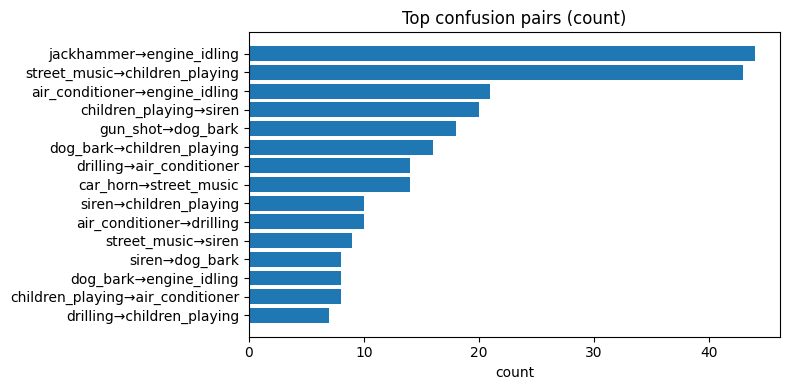

In [74]:
plt.figure(figsize=(8, 4))
plt.barh(
    [f"{r.true}→{r.pred}" for r in pairs_df.itertuples()],
    pairs_df["count"].values
)
plt.gca().invert_yaxis()
plt.title("Top confusion pairs (count)")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In [75]:
def audit_table(rows, y_true, y_pred, conf, probs, label_names, topk=3):
    """
    rows: indices into y_true/y_pred/conf arrays (the same indices you already have)
    """
    out = []
    for r in rows:
        t = int(y_true[r])
        p = int(y_pred[r])
        c = float(conf[r])

        # top-k predicted classes for context
        pk = probs[r]  # (C,)
        top_idx = np.argsort(-pk)[:topk]
        top_str = ", ".join([f"{label_names[i]}:{pk[i]:.2f}" for i in top_idx])

        out.append({
            "row": int(r),
            "true": label_names[t],
            "pred": label_names[p],
            "conf": c,
            "top_probs": top_str,
        })

    df = pd.DataFrame(out).sort_values("conf", ascending=True).reset_index(drop=True)
    return df

### Least-Confident Correct Predictions

In [76]:
correct = np.where(y_true == y_pred)[0]
correct_sorted = correct[np.argsort(conf[correct])]  # ascending confidence

top_k = 6
low_conf_correct = correct_sorted[:top_k]

df_low = audit_table(low_conf_correct, y_true, y_pred, conf, probs, label_names, topk=3)
df_low

,row,true,pred,conf,top_probs
0,451,jackhammer,jackhammer,0.235204,"jackhammer:0.24, drilling:0.18, engine_idling:..."
1,742,dog_bark,dog_bark,0.237635,"dog_bark:0.24, gun_shot:0.21, car_horn:0.19"
2,458,jackhammer,jackhammer,0.244523,"jackhammer:0.24, gun_shot:0.19, dog_bark:0.17"
3,493,air_conditioner,air_conditioner,0.248996,"air_conditioner:0.25, engine_idling:0.19, chil..."
4,205,gun_shot,gun_shot,0.250017,"gun_shot:0.25, jackhammer:0.23, dog_bark:0.21"
5,339,air_conditioner,air_conditioner,0.251663,"air_conditioner:0.25, engine_idling:0.22, jack..."


### Most-Confident Incorrect Predictions

In [77]:
wrong = np.where(y_true != y_pred)[0]
wrong_sorted = wrong[np.argsort(-conf[wrong])]  # descending confidence
top_conf_wrong = wrong_sorted[:6]

df_wrong = audit_table(top_conf_wrong, y_true, y_pred, conf, probs, label_names, topk=3)
df_wrong

,row,true,pred,conf,top_probs
0,600,car_horn,street_music,0.939936,"street_music:0.94, children_playing:0.03, sire..."
1,591,car_horn,street_music,0.940143,"street_music:0.94, children_playing:0.02, dog_..."
2,592,car_horn,street_music,0.957380,"street_music:0.96, children_playing:0.02, dog_..."
3,599,car_horn,street_music,0.970546,"street_music:0.97, children_playing:0.02, sire..."
4,598,car_horn,street_music,0.979373,"street_music:0.98, dog_bark:0.01, children_pla..."
5,503,children_playing,dog_bark,0.991172,"dog_bark:0.99, children_playing:0.01, street_m..."


In [78]:
def show_spec_grid(rows, test_ds, y_true, y_pred, conf, label_names, ncols=3, title=""):
    n = len(rows)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(ncols * 5, nrows * 3.5))
    if title:
        plt.suptitle(title, y=1.02, fontsize=14)

    for k, r in enumerate(rows):
        x, _ = test_ds[int(r)]  # <-- IMPORTANT: if your `r` is NOT a dataset index, see note below
        spec = x.squeeze(0).numpy()  # (n_mels, time)

        ax = plt.subplot(nrows, ncols, k + 1)
        ax.imshow(spec, aspect="auto", origin="lower")
        ax.set_title(
            f"T:{label_names[int(y_true[r])]}\nP:{label_names[int(y_pred[r])]}, conf={conf[r]:.2f}",
            fontsize=10
        )
        ax.set_xlabel("time")
        ax.set_ylabel("mel")

    plt.tight_layout()
    plt.show()

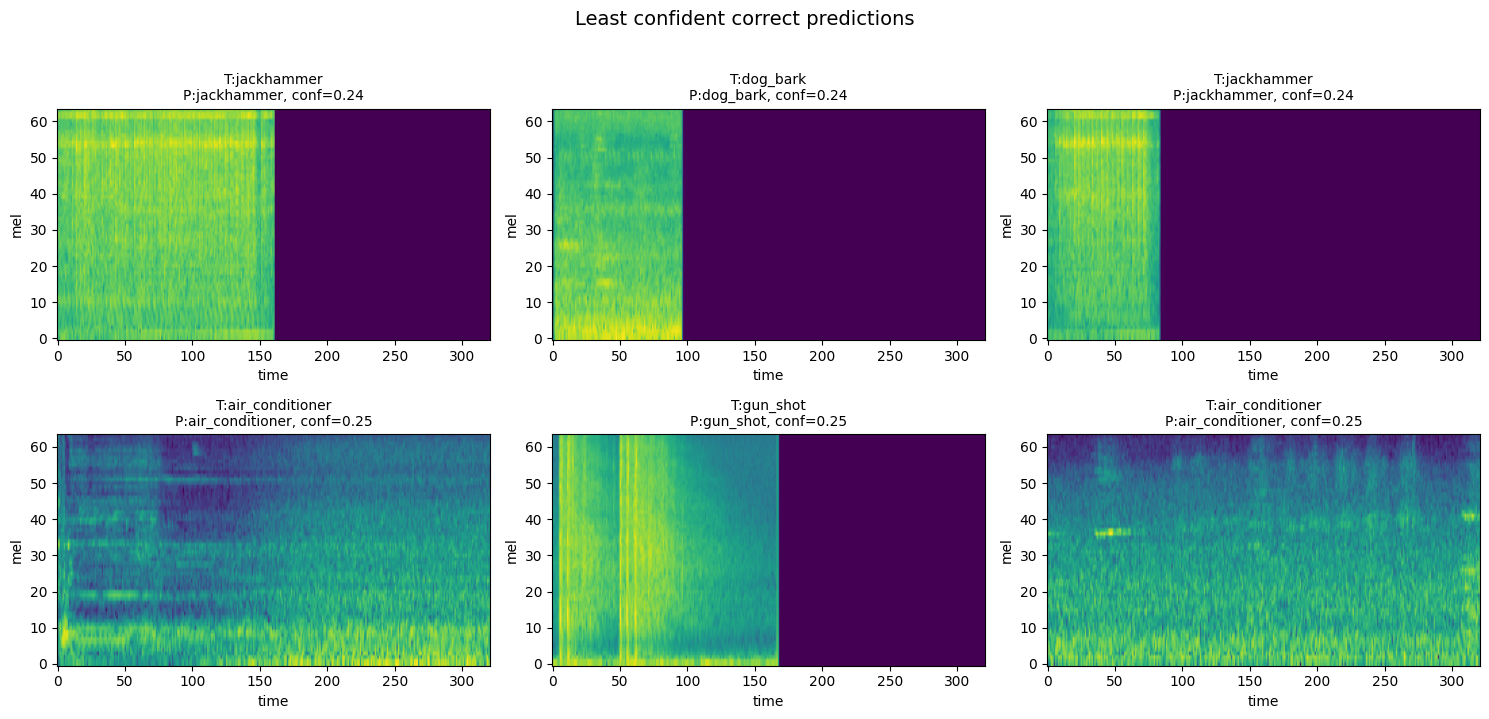

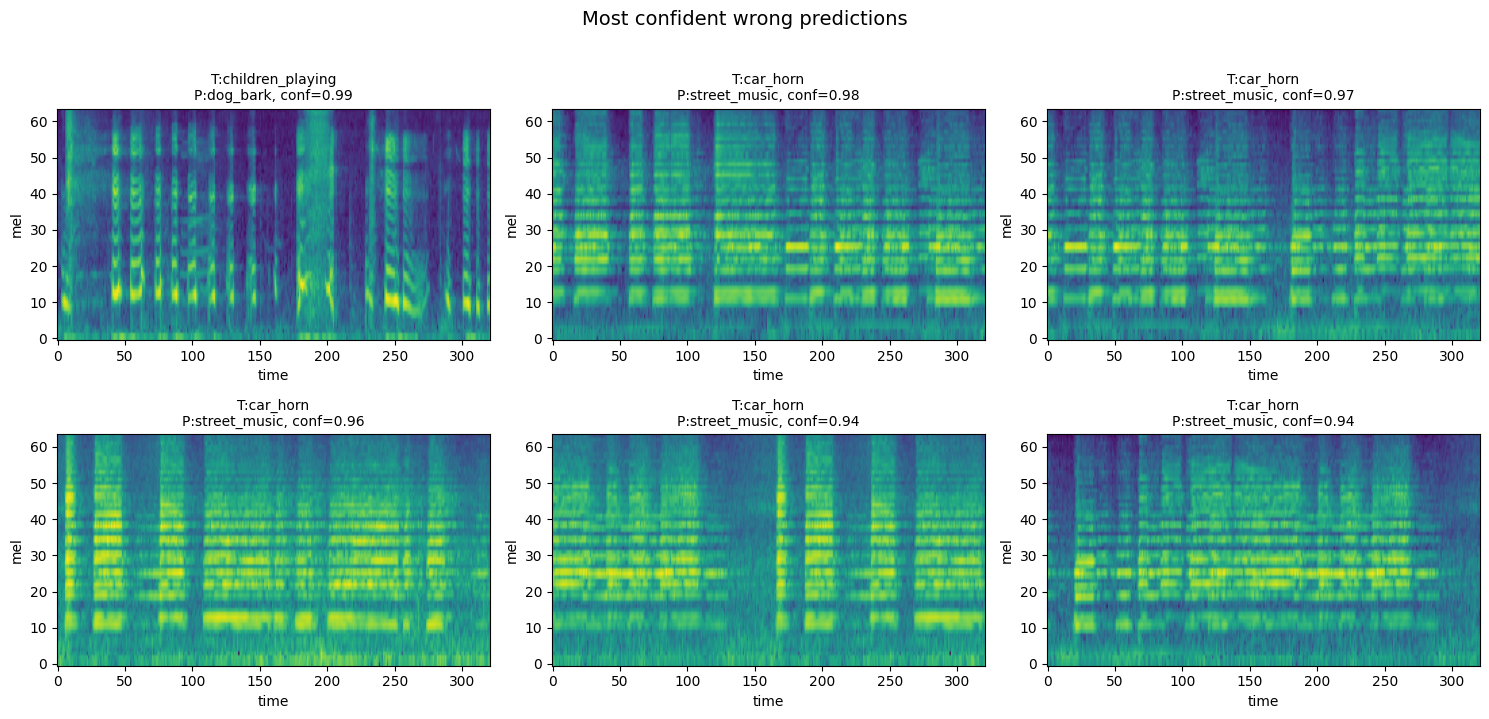

In [79]:
show_spec_grid(low_conf_correct, test_ds, y_true, y_pred, conf, label_names,
              title="Least confident correct predictions")
show_spec_grid(top_conf_wrong, test_ds, y_true, y_pred, conf, label_names,
              title="Most confident wrong predictions")

## 13. Optional improvements (choose 1–2)

In this section we run a controlled improvement experiment on the CNN baseline.

**Goal:** Keep the story clean by changing one thing at a time and measuring impact on validation performance.  
**Rule:** Same data split, same model architecture, same epochs, same batch size — only the improvement changes.  

We’ll start with one audio-native regularization technique:

**SpecAugment-lite**
Randomly mask small time regions and frequency bands in the log-mel spectrogram during training only.
Hypothesis: This reduces overfitting and improves generalization because the model can’t rely on overly-specific local patterns.


### SpecAugment-lite
**What it is:** randomly “blank out” small time regions and small frequency bands in the log-mel during training only.  
**Why it exists:** makes the model robust to occlusion / noise / partial information, reduces overfitting.

#### Where to apply SpecAugment

We apply it inside the Dataset.__getitem__ method, after converting the waveform to log-mel (mel_db) and before adding the channel dimension (unsqueeze(0)).

That keeps augmentation:

train-only (self.train == True)

fast (feature-space, not waveform-space)

shape-stable (doesn’t break the CNN)

In [44]:
# In UrbanSoundTorchDataset.__getitem__, insert this after mel_db is computed:
#
#   if self.train:
#       mel_db = spec_augment_lite(mel_db, time_mask_param=20, freq_mask_param=8)
#
# Your final __getitem__ should look like:

def __getitem__(self, idx):
    row = self.split[idx]

    w, sr = self._decode_audio(row)

    if sr != TARGET_SR:
        w = torchaudio.functional.resample(w, sr, TARGET_SR)
        sr = TARGET_SR

    w = pad_or_crop(w, CLIP_SAMPLES, train=self.train)

    mel = mel_extractor(w.unsqueeze(0))
    mel_db = to_db(mel).squeeze(0)

    # ✅ SpecAugment-lite (train only)
    if self.train:
        mel_db = spec_augment_lite(mel_db, time_mask_param=20, freq_mask_param=8)

    x = mel_db.unsqueeze(0)  # (1, n_mels, time)
    y = int(row["classID"])
    return x, y


In [54]:
# --- 13.5 Controlled experiment runner: Baseline vs SpecAugment-lite ---

from copy import deepcopy
import torch.nn as nn

def run_experiment(
    experiment_name: str,
    train_aug: bool,
    class_weighting: bool = False,
    epochs: int = 10,
    lr: float = 1e-3,
    batch_size: int = 64,
    max_train_items: int = 4000,
    max_val_items: int = 1000,
):
    """
    Runs one training experiment and returns a dict with:
      - history
      - best_val_acc
      - best_val_loss
      - best_state
      - final_test_acc (optional if test_dl exists)
    """

    # 1) Build datasets
    train_ds = UrbanSoundTorchDataset(train_split, train=True,  max_items=max_train_items)
    val_ds   = UrbanSoundTorchDataset(val_split,   train=False, max_items=max_val_items)
    test_ds  = UrbanSoundTorchDataset(test_split,  train=False, max_items=max_val_items)

    # 2) Toggle augmentation behavior via dataset flag
    # (we already use self.train inside __getitem__ for SpecAugment,
    # so train_aug controls whether train_ds.train is True)
    train_ds.train = train_aug

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

    # 3) Model (fresh init for a fair comparison)
    model = SmallAudioCNN(n_classes=num_classes).to(device)

    # 4) Loss (optional class weighting)
    if class_weighting:
        counts = Counter(train_split["classID"])
        freq = np.array([counts[i] for i in range(num_classes)], dtype=np.float32)
        weights = (1.0 / freq)
        weights = weights / weights.mean()
        class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    else:
        loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_val = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, loss_fn, optimizer, device)
        va_loss, va_acc = evaluate(model, val_dl, loss_fn, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"{experiment_name} | Epoch {epoch:02d} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.3f}")

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # evaluate once on test
    test_loss, test_acc = evaluate(model, test_dl, loss_fn, device)

    return {
        "name": experiment_name,
        "history": history,
        "best_val_loss": min(history["val_loss"]),
        "best_val_acc": max(history["val_acc"]),
        "test_acc": test_acc,
    }


In [55]:
# 
# run experiments
# 
res_baseline = run_experiment(
    experiment_name="Baseline CNN",
    train_aug=False,     # train_ds.train = False => no SpecAugment path
    class_weighting=False,
    epochs=10,
    lr=1e-3,
)

# SpecAugment-lite: enabled during training
res_specaug = run_experiment(
    experiment_name="CNN + SpecAugment-lite",
    train_aug=True,      # train_ds.train = True => SpecAugment path runs
    class_weighting=False,
    epochs=10,
    lr=1e-3,
)

res_baseline["best_val_acc"], res_specaug["best_val_acc"]

Baseline CNN | Epoch 01 | train loss 1.8701 acc 0.350 | val loss 1.6236 acc 0.498
Baseline CNN | Epoch 02 | train loss 1.6061 acc 0.443 | val loss 1.5310 acc 0.384
Baseline CNN | Epoch 03 | train loss 1.4761 acc 0.495 | val loss 1.4025 acc 0.439
Baseline CNN | Epoch 04 | train loss 1.3521 acc 0.554 | val loss 1.2782 acc 0.567
Baseline CNN | Epoch 05 | train loss 1.2282 acc 0.610 | val loss 1.2460 acc 0.618
Baseline CNN | Epoch 06 | train loss 1.1442 acc 0.633 | val loss 1.0745 acc 0.586
Baseline CNN | Epoch 07 | train loss 1.0759 acc 0.670 | val loss 1.3886 acc 0.473
Baseline CNN | Epoch 08 | train loss 1.0274 acc 0.679 | val loss 1.0629 acc 0.638
Baseline CNN | Epoch 09 | train loss 0.9441 acc 0.721 | val loss 1.2334 acc 0.488
Baseline CNN | Epoch 10 | train loss 0.8991 acc 0.731 | val loss 1.2409 acc 0.565
CNN + SpecAugment-lite | Epoch 01 | train loss 1.9257 acc 0.290 | val loss 1.8054 acc 0.248
CNN + SpecAugment-lite | Epoch 02 | train loss 1.7112 acc 0.384 | val loss 1.5938 acc 0.

(0.6384803921568627, 0.5845588235294118)

In [61]:
results_df = pd.DataFrame([
    {"Model": res_baseline["name"], "Best Val Acc": res_baseline["best_val_acc"], "Test Acc": res_baseline["test_acc"]},
    {"Model": res_specaug["name"], "Best Val Acc": res_specaug["best_val_acc"], "Test Acc": res_specaug["test_acc"]},
])

results_df

,Model,Best Val Acc,Test Acc
0,Baseline CNN,0.638480,0.661888
1,CNN + SpecAugment-lite,0.584559,0.578256


#### Comparison & Interpretation

**SpecAugment-lite did not improve performance for this model and dataset.**  
Both validation and test accuracy decreased relative to the baseline.

This suggests that for short environmental sound clips, aggressive time/frequency masking may remove critical transient information, particularly for impulsive classes such as dog bark or gunshot.

Additionally, the baseline CNN may not have sufficient capacity to
benefit from stronger regularization.  


#### Note on Negative Results
Negative results are still informative. This experiment highlights that
data augmentation strategies must be matched to both dataset characteristics
and model capacity. Blindly applying standard techniques can degrade
performance.



### Class Weighting
**What it is:** give more loss weight to underrepresented classes.  

**Why it exists:** otherwise the model can “cheat” by doing better on frequent classes and ignoring rare ones.

In [58]:
# compute weights from training split
counts = Counter(train_split["classID"])
num_classes = len(set(train_split["classID"]))

freq = np.array([counts[i] for i in range(num_classes)], dtype=np.float32)
weights = 1.0 / freq
weights = weights / weights.mean()  # normalize so average weight ~1

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("class counts:", freq.astype(int))
print("class weights:", weights)

class counts: [800 364 800 800 800 818 311 822 764 800]
class weights: [0.78317726 1.7212688  0.78317726 0.78317726 0.78317726 0.7659436
 2.0146039  0.7622163  0.82008094 0.78317726]


## 14. Conclusions & next steps
### Key takeaways
- A simple CNN trained on **log-mel spectrograms** achieves solid performance on UrbanSound8K, reaching ~**66% test accuracy** without heavy tuning.
- The **baseline model outperformed the SpecAugment-lite variant** in this setup, suggesting that augmentation strength and training duration need to be carefully matched to model capacity.
- Error analysis shows **consistent confusion between acoustically similar classes** (e.g. *jackhammer ↔ engine_idling*, *street_music ↔ children_playing*), indicating that **many errors are perceptual rather than random**.
- Low-confidence correct predictions often occur when multiple sound sources overlap, highlighting the limits of short fixed-length clips.

### What this notebook demonstrates
- An end-to-end **audio classification workflow in PyTorch**, including dataset handling, feature extraction, training, evaluation, and error analysis.
- Controlled experimentation with **clear baselines and fair comparisons**, rather than aggressive tuning.
- Practical model debugging using **confusion matrices, confidence analysis, and qualitative spectrogram inspection**.

### Next steps (future work)
- Tune augmentation strength (e.g. frequency/time masking ranges) and training length to better evaluate SpecAugment.
- Explore **slightly deeper CNNs or residual blocks** to improve class separability.
- Incorporate **class weighting or focal loss** to address class imbalance.
- Compare spectrogram-based CNNs with **raw-waveform or transformer-based models**.
- Evaluate robustness using **longer clips or multi-segment aggregation** at inference time.

Overall, this project serves as a strong, interpretable baseline and a foundation for more advanced audio modeling experiments.